# Universidad del Valle de Guatemala
# Inteligencia Artificial CC3085
# Proyecto 1
## Opción elegida: (A) Predicción de Tarifas de Transporte en NYC
## Integrantes del grupo:
### - Joel Jaquez #23369
### - Luis Gonzalez #23353
### - Diego Patzan #23525
### Fecha de entrega: Lunes de 6 de abril 2026

# Importación de librerias

In [4]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


# Carga del dataset

In [5]:
# Carga del dataset
SAMPLE_SIZE = 1_000_000

df = pd.read_csv(
    '../data/train.csv',
    nrows=SAMPLE_SIZE,
    parse_dates=['pickup_datetime']
)

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset cargado: 1,000,000 filas x 8 columnas


# Fase 1: Análisis Exploratorio y Limpieza

In [6]:
# Vista general
print("=" * 50)
print("PRIMERAS 5 FILAS")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("TIPOS DE DATOS")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
display(df.describe())

print("\n" + "=" * 50)
print("VALORES NULOS")
print("=" * 50)
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(nulos)

PRIMERAS 5 FILAS


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5000,2009-06-15 17:26:21+00:00,-73.8443,40.7213,-73.8416,40.7123,1
1,2010-01-05 16:52:16.0000002,16.9000,2010-01-05 16:52:16+00:00,-74.0160,40.7113,-73.9793,40.7820,1
2,2011-08-18 00:35:00.00000049,5.7000,2011-08-18 00:35:00+00:00,-73.9827,40.7613,-73.9912,40.7506,2
3,2012-04-21 04:30:42.0000001,7.7000,2012-04-21 04:30:42+00:00,-73.9871,40.7331,-73.9916,40.7581,1
4,2010-03-09 07:51:00.000000135,5.3000,2010-03-09 07:51:00+00:00,-73.9681,40.7680,-73.9567,40.7838,1



TIPOS DE DATOS
key                                  str
fare_amount                      float64
pickup_datetime      datetime64[us, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dtype: object

ESTADÍSTICAS DESCRIPTIVAS


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1000000.0000,1000000.0000,1000000.0000,999990.0000,999990.0000,1000000.0000
mean,11.3481,-72.5266,39.9290,-72.5279,39.9200,1.6849
std,9.8221,12.0579,7.6262,11.3245,8.2014,1.3239
min,-44.9000,-3377.6809,-3116.2854,-3383.2966,-3114.3386,0.0000
25%,6.0000,-73.9921,40.7350,-73.9914,40.7340,1.0000
50%,8.5000,-73.9818,40.7527,-73.9801,40.7532,1.0000
75%,12.5000,-73.9671,40.7672,-73.9637,40.7681,2.0000
max,500.0000,2522.2713,2621.6284,45.5816,1651.5534,208.0000



VALORES NULOS
                   Nulos  Porcentaje (%)
key                    0          0.0000
fare_amount            0          0.0000
pickup_datetime        0          0.0000
pickup_longitude       0          0.0000
pickup_latitude        0          0.0000
dropoff_longitude     10          0.0000
dropoff_latitude      10          0.0000
passenger_count        0          0.0000


## Análisis Exploratorio y Limpieza

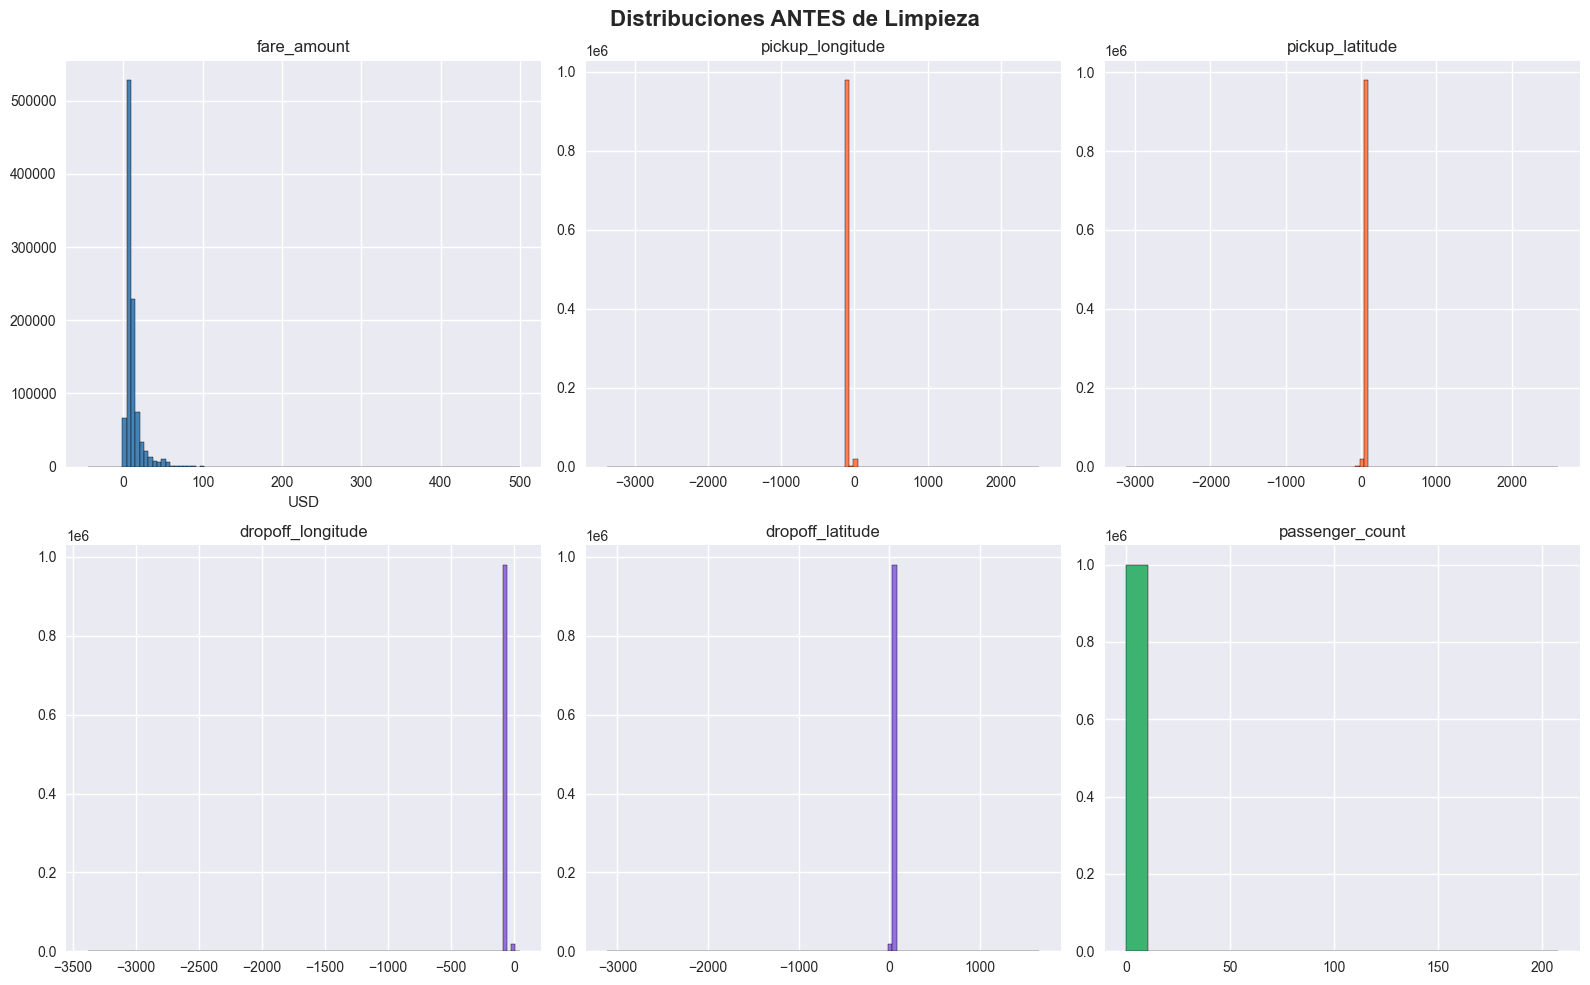

Grafica guardada


In [7]:
# Análisis Exploratorio: Distribuciones iniciales

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones ANTES de Limpieza', fontsize=16, fontweight='bold')

axes[0,0].hist(df['fare_amount'], bins=100, color='steelblue', edgecolor='black')
axes[0,0].set_title('fare_amount')
axes[0,0].set_xlabel('USD')

axes[0,1].hist(df['pickup_longitude'], bins=100, color='coral', edgecolor='black')
axes[0,1].set_title('pickup_longitude')

axes[0,2].hist(df['pickup_latitude'], bins=100, color='coral', edgecolor='black')
axes[0,2].set_title('pickup_latitude')

axes[1,0].hist(df['dropoff_longitude'], bins=100, color='mediumpurple', edgecolor='black')
axes[1,0].set_title('dropoff_longitude')

axes[1,1].hist(df['dropoff_latitude'], bins=100, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('dropoff_latitude')

axes[1,2].hist(df['passenger_count'], bins=20, color='mediumseagreen', edgecolor='black')
axes[1,2].set_title('passenger_count')

plt.tight_layout()
plt.savefig('distribucion_antes_limpieza.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

In [8]:
# Análisis de Outliers (antes de limpiar)

print("=" * 55)
print("ANALISIS DE OUTLIERS - VALORES PROBLEMATICOS")
print("=" * 55)

print(f"\nfare_amount negativos o cero:  {(df['fare_amount'] <= 0).sum():,}")
print(f"fare_amount > $200:            {(df['fare_amount'] > 200).sum():,}")

print(f"\nCoordenadas fuera de NYC:")
LAT_MIN, LAT_MAX = 40.4774, 41.0755
LON_MIN, LON_MAX = -74.2591, -71.6966

fuera_pickup = (
    ~df['pickup_latitude'].between(LAT_MIN, LAT_MAX) |
    ~df['pickup_longitude'].between(LON_MIN, LON_MAX)
)
fuera_dropoff = (
    ~df['dropoff_latitude'].between(LAT_MIN, LAT_MAX) |
    ~df['dropoff_longitude'].between(LON_MIN, LON_MAX)
)
print(f"   - Pickup fuera de NYC:    {fuera_pickup.sum():,}")
print(f"   - Dropoff fuera de NYC:   {fuera_dropoff.sum():,}")

print(f"\npassenger_count = 0:          {(df['passenger_count'] == 0).sum():,}")
print(f"passenger_count > 7:          {(df['passenger_count'] > 7).sum():,}")

ANALISIS DE OUTLIERS - VALORES PROBLEMATICOS

fare_amount negativos o cero:  67
fare_amount > $200:            38

Coordenadas fuera de NYC:
   - Pickup fuera de NYC:    20,297
   - Dropoff fuera de NYC:   20,276

passenger_count = 0:          3,565
passenger_count > 7:          1


In [9]:
# LIMPIEZA COMPLETA

df_clean = df.copy()
print(f"Filas iniciales: {len(df_clean):,}")

# 1. Eliminar nulos
df_clean = df_clean.dropna()
print(f"Tras eliminar nulos:           {len(df_clean):,}")

# 2. Limpieza de etiquetas (fare_amount)
df_clean = df_clean[df_clean['fare_amount'] > 0]
df_clean = df_clean[df_clean['fare_amount'] <= 200]
print(f"Tras limpiar fare_amount:      {len(df_clean):,}")

# 3. Limpieza geográfica (bounding box NYC)
df_clean = df_clean[
    df_clean['pickup_latitude'].between(LAT_MIN, LAT_MAX)  &
    df_clean['pickup_longitude'].between(LON_MIN, LON_MAX) &
    df_clean['dropoff_latitude'].between(LAT_MIN, LAT_MAX) &
    df_clean['dropoff_longitude'].between(LON_MIN, LON_MAX)
]
print(f"Tras limpieza geografica:      {len(df_clean):,}")

# 4. Limpieza de passenger_count
df_clean = df_clean[df_clean['passenger_count'].between(1, 7)]
print(f"Tras limpiar passenger_count:  {len(df_clean):,}")

# Resumen
eliminadas = 1_000_000 - len(df_clean)
print(f"\nFilas eliminadas: {eliminadas:,} ({eliminadas/1_000_000*100:.2f}%)")
print(f"Dataset limpio:   {len(df_clean):,} filas")

Filas iniciales: 1,000,000
Tras eliminar nulos:           999,990
Tras limpiar fare_amount:      999,885
Tras limpieza geografica:      978,475
Tras limpiar passenger_count:  974,993

Filas eliminadas: 25,007 (2.50%)
Dataset limpio:   974,993 filas


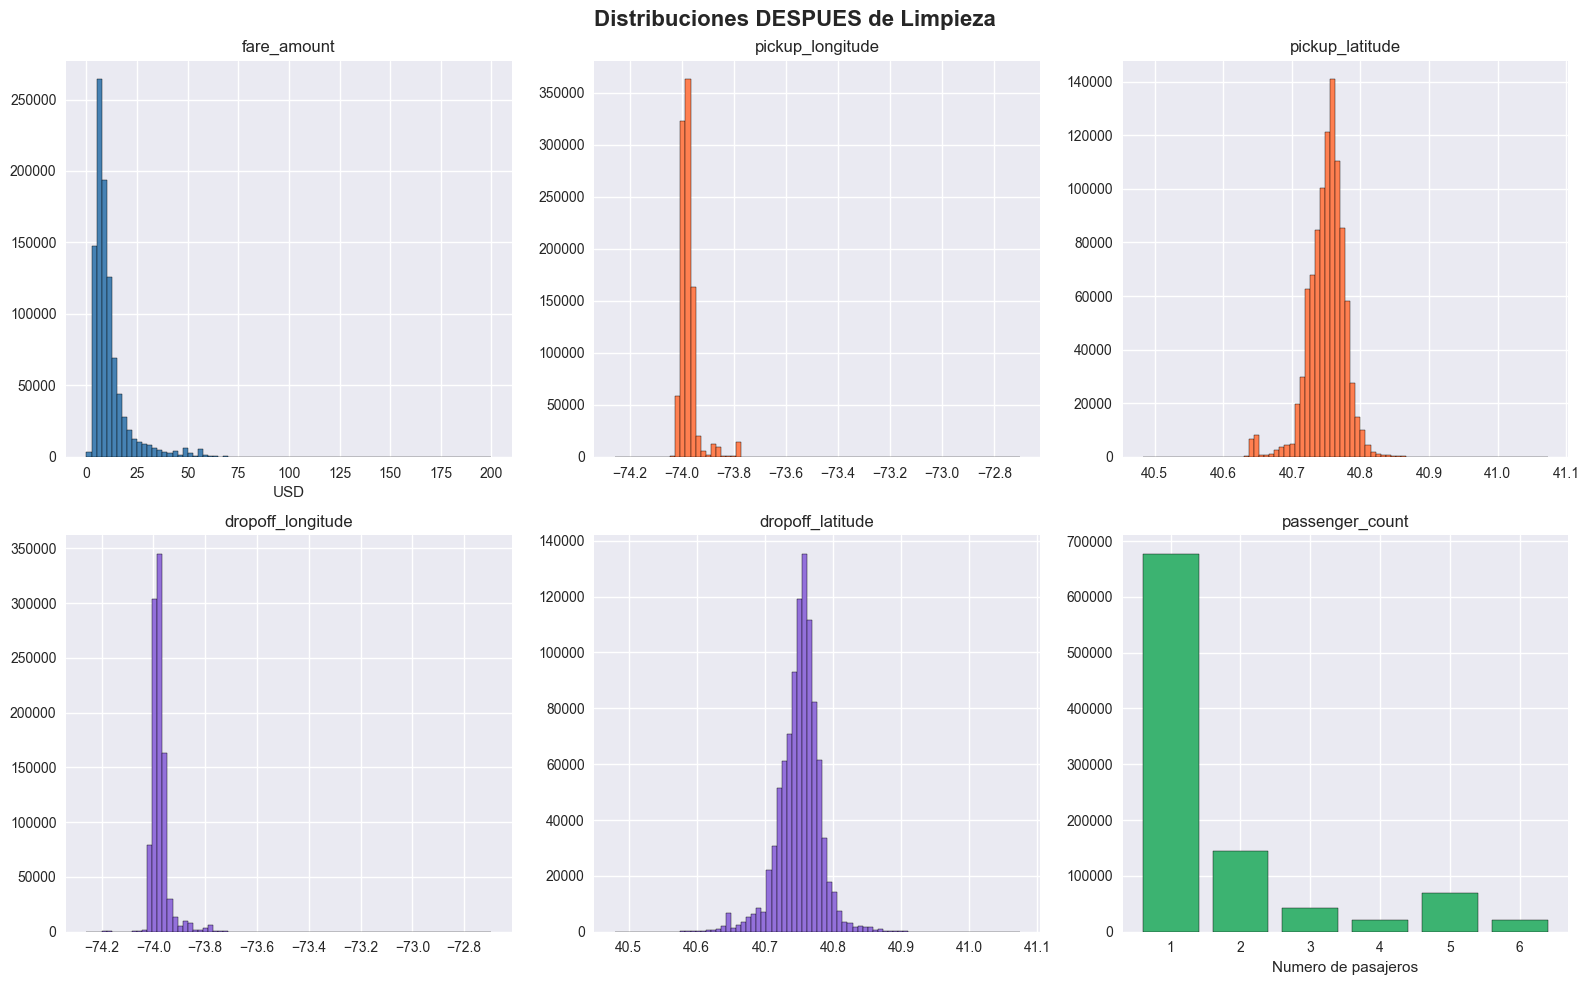

Grafica guardada


In [10]:
# Distribuciones DESPUÉS de limpieza

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones DESPUES de Limpieza', fontsize=16, fontweight='bold')

axes[0,0].hist(df_clean['fare_amount'], bins=80, color='steelblue', edgecolor='black')
axes[0,0].set_title('fare_amount')
axes[0,0].set_xlabel('USD')

axes[0,1].hist(df_clean['pickup_longitude'], bins=80, color='coral', edgecolor='black')
axes[0,1].set_title('pickup_longitude')

axes[0,2].hist(df_clean['pickup_latitude'], bins=80, color='coral', edgecolor='black')
axes[0,2].set_title('pickup_latitude')

axes[1,0].hist(df_clean['dropoff_longitude'], bins=80, color='mediumpurple', edgecolor='black')
axes[1,0].set_title('dropoff_longitude')

axes[1,1].hist(df_clean['dropoff_latitude'], bins=80, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('dropoff_latitude')

axes[1,2].bar(
    df_clean['passenger_count'].value_counts().sort_index().index,
    df_clean['passenger_count'].value_counts().sort_index().values,
    color='mediumseagreen', edgecolor='black'
)
axes[1,2].set_title('passenger_count')
axes[1,2].set_xlabel('Numero de pasajeros')

plt.tight_layout()
plt.savefig('distribucion_despues_limpieza.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

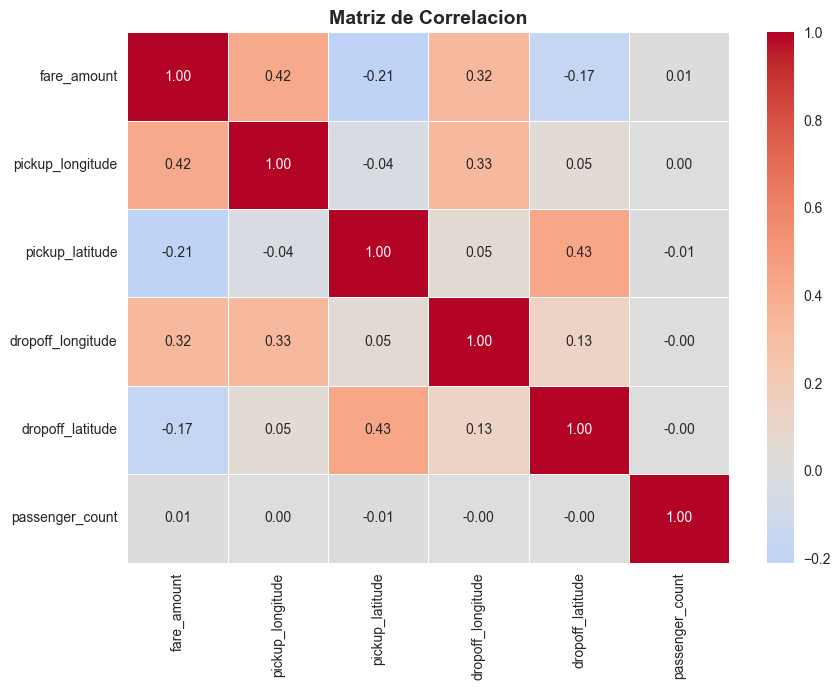

Grafica guardada


In [11]:
# Mapa de calor de correlaciones

cols_corr = ['fare_amount', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_clean[cols_corr].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Matriz de Correlacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

# Fase 2: Ingeniería Característica

In [12]:

# Distancia Haversine

#Calcula la distancia en km entre dos puntos geograficos usando la formula de Haversine.
def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Radio de la Tierra en km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# Aplicar Haversine al dataset limpio
df_clean['distance_km'] = haversine(
    df_clean['pickup_latitude'].values,
    df_clean['pickup_longitude'].values,
    df_clean['dropoff_latitude'].values,
    df_clean['dropoff_longitude'].values
)

print("Estadisticas de distancia_km:")
print(df_clean['distance_km'].describe())

Estadisticas de distancia_km:
count   974993.0000
mean         3.3151
std          3.5812
min          0.0000
25%          1.2546
50%          2.1534
75%          3.9180
max        107.1358
Name: distance_km, dtype: float64


In [13]:
# Filtrar distancias imposibles (outliers restantes)

print(f"Filas antes de filtrar distancias: {len(df_clean):,}")

# Eliminar viajes con distancia 0 (pickup == dropoff) o mayores a 100 km
df_clean = df_clean[df_clean['distance_km'] > 0]
df_clean = df_clean[df_clean['distance_km'] <= 100]

print(f"Filas despues de filtrar distancias: {len(df_clean):,}")

Filas antes de filtrar distancias: 974,993
Filas despues de filtrar distancias: 964,769


In [14]:
# Variables Temporales

# Extraer componentes del timestamp
df_clean['hour']       = df_clean['pickup_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['pickup_datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo
df_clean['month']      = df_clean['pickup_datetime'].dt.month
df_clean['year']       = df_clean['pickup_datetime'].dt.year

print("Variables temporales creadas:")
print(df_clean[['pickup_datetime', 'hour', 'day_of_week', 'month', 'year']].head(8))

Variables temporales creadas:
            pickup_datetime  hour  day_of_week  month  year
0 2009-06-15 17:26:21+00:00    17            0      6  2009
1 2010-01-05 16:52:16+00:00    16            1      1  2010
2 2011-08-18 00:35:00+00:00     0            3      8  2011
3 2012-04-21 04:30:42+00:00     4            5      4  2012
4 2010-03-09 07:51:00+00:00     7            1      3  2010
5 2011-01-06 09:50:45+00:00     9            3      1  2011
6 2012-11-20 20:35:00+00:00    20            1     11  2012
7 2012-01-04 17:22:00+00:00    17            2      1  2012


In [15]:
# Zonas de Interes (Aeropuertos)

# Coordenadas aproximadas de los aeropuertos principales de NYC
AIRPORTS = {
    'jfk':      {'lat': 40.6413, 'lon': -73.7781, 'radio': 0.05},
    'laguardia': {'lat': 40.7769, 'lon': -73.8740, 'radio': 0.03},
    'newark':   {'lat': 40.6895, 'lon': -74.1745, 'radio': 0.04},
}

def cerca_aeropuerto(lat, lon, aeropuerto):
    """Retorna 1 si el punto esta dentro del radio del aeropuerto."""
    a = AIRPORTS[aeropuerto]
    return ((np.abs(lat - a['lat']) < a['radio']) &
            (np.abs(lon - a['lon']) < a['radio'])).astype(int)

# Variable binaria: origen cerca de algun aeropuerto
df_clean['pickup_jfk']       = cerca_aeropuerto(df_clean['pickup_latitude'], df_clean['pickup_longitude'], 'jfk')
df_clean['pickup_laguardia'] = cerca_aeropuerto(df_clean['pickup_latitude'], df_clean['pickup_longitude'], 'laguardia')
df_clean['pickup_newark']    = cerca_aeropuerto(df_clean['pickup_latitude'], df_clean['pickup_longitude'], 'newark')

# Variable binaria: destino cerca de algun aeropuerto
df_clean['dropoff_jfk']       = cerca_aeropuerto(df_clean['dropoff_latitude'], df_clean['dropoff_longitude'], 'jfk')
df_clean['dropoff_laguardia'] = cerca_aeropuerto(df_clean['dropoff_latitude'], df_clean['dropoff_longitude'], 'laguardia')
df_clean['dropoff_newark']    = cerca_aeropuerto(df_clean['dropoff_latitude'], df_clean['dropoff_longitude'], 'newark')

airport_cols = ['pickup_jfk', 'pickup_laguardia', 'pickup_newark',
                'dropoff_jfk', 'dropoff_laguardia', 'dropoff_newark']

print("Viajes relacionados con aeropuertos:")
print(df_clean[airport_cols].sum())

Viajes relacionados con aeropuertos:
pickup_jfk           14907
pickup_laguardia     20935
pickup_newark           61
dropoff_jfk           8178
dropoff_laguardia    15557
dropoff_newark        1310
dtype: int64


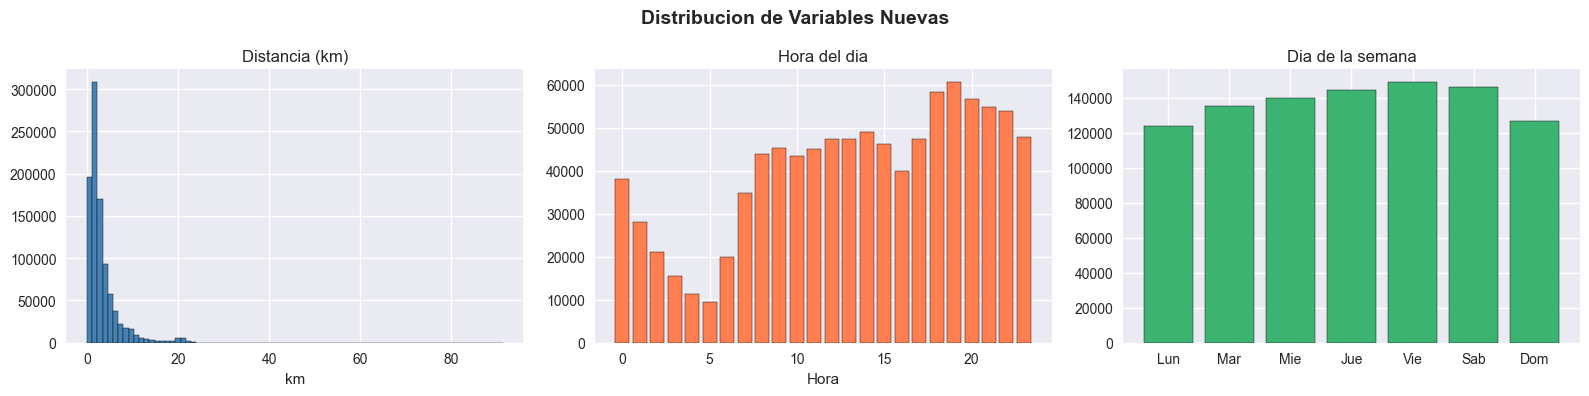

Grafica guardada


In [16]:
# Visualizacion del Feature Engineering

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribucion de Variables Nuevas', fontsize=14, fontweight='bold')

# Distancia
axes[0].hist(df_clean['distance_km'], bins=80, color='steelblue', edgecolor='black')
axes[0].set_title('Distancia (km)')
axes[0].set_xlabel('km')

# Hora del dia
axes[1].bar(
    df_clean['hour'].value_counts().sort_index().index,
    df_clean['hour'].value_counts().sort_index().values,
    color='coral', edgecolor='black'
)
axes[1].set_title('Hora del dia')
axes[1].set_xlabel('Hora')

# Dia de la semana
dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
axes[2].bar(
    df_clean['day_of_week'].value_counts().sort_index().index,
    df_clean['day_of_week'].value_counts().sort_index().values,
    color='mediumseagreen', edgecolor='black'
)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dias)
axes[2].set_title('Dia de la semana')

plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

In [17]:
#  Resumen final del dataset con todas las features

print(f"Shape final del dataset: {df_clean.shape}")
print(f"\nColumnas disponibles:")
print(list(df_clean.columns))
print(f"\nPrimeras filas con todas las features:")
display(df_clean.head())

Shape final del dataset: (964769, 19)

Columnas disponibles:
['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distance_km', 'hour', 'day_of_week', 'month', 'year', 'pickup_jfk', 'pickup_laguardia', 'pickup_newark', 'dropoff_jfk', 'dropoff_laguardia', 'dropoff_newark']

Primeras filas con todas las features:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,day_of_week,month,year,pickup_jfk,pickup_laguardia,pickup_newark,dropoff_jfk,dropoff_laguardia,dropoff_newark
0,2009-06-15 17:26:21.0000001,4.5000,2009-06-15 17:26:21+00:00,-73.8443,40.7213,-73.8416,40.7123,1,1.0308,17,0,6,2009,0,0,0,0,0,0
1,2010-01-05 16:52:16.0000002,16.9000,2010-01-05 16:52:16+00:00,-74.0160,40.7113,-73.9793,40.7820,1,8.4501,16,1,1,2010,0,0,0,0,0,0
2,2011-08-18 00:35:00.00000049,5.7000,2011-08-18 00:35:00+00:00,-73.9827,40.7613,-73.9912,40.7506,2,1.3895,0,3,8,2011,0,0,0,0,0,0
3,2012-04-21 04:30:42.0000001,7.7000,2012-04-21 04:30:42+00:00,-73.9871,40.7331,-73.9916,40.7581,1,2.7993,4,5,4,2012,0,0,0,0,0,0
4,2010-03-09 07:51:00.000000135,5.3000,2010-03-09 07:51:00+00:00,-73.9681,40.7680,-73.9567,40.7838,1,1.9992,7,1,3,2010,0,0,0,0,0,0


# Fase 3: Partición Train/Test

In [19]:
from sklearn.model_selection import train_test_split

# Features (variables de entrada)
X = df_clean[['distance_km', 'hour', 'day_of_week', 'month', 'year',
              'passenger_count', 'pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude',
              'pickup_jfk', 'pickup_laguardia', 'pickup_newark',
              'dropoff_jfk', 'dropoff_laguardia', 'dropoff_newark']]

# Target (variable a predecir)
y = df_clean['fare_amount']

# División 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42  # garantiza reproducibilidad
)

print("Particion completada:")
print(f"  X_train: {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas")
print(f"  X_test:  {X_test.shape[0]:,} filas x {X_test.shape[1]} columnas")
print(f"  y_train: {y_train.shape[0]:,} valores")
print(f"  y_test:  {y_test.shape[0]:,} valores")
print(f"\n  Train: {X_train.shape[0]/len(X)*100:.1f}%")
print(f"  Test:  {X_test.shape[0]/len(X)*100:.1f}%")

Particion completada:
  X_train: 771,815 filas x 16 columnas
  X_test:  192,954 filas x 16 columnas
  y_train: 771,815 valores
  y_test:  192,954 valores

  Train: 80.0%
  Test:  20.0%
